# v4 — resep v2 (LB 0.91514) + variance reduction, 3 submission untuk isolasi faktor

**Kenapa bukan lanjutan v3?** EDA round 3 (`eda/12–20`, ringkasan `eda/README.md`):
- v3 (0.89077) beda dari v2 hanya 59 baris; forensik LB → v3 benar di ±20–30% baris yang ia ubah. Page tiles merusak: label dataset ini mengikuti **genre/sumber halaman**, tile membaca huruf lokal.
- CV tidak bisa membedakan v2 vs v3 (proxy terkoreksi .945 vs .952); silver set yang presisi hanya berisi kasus mudah → **LB satu-satunya validasi** untuk perubahan preprocessing.
- Koreksi prior (EM/BBSE) dan ensemble v2+v3 tidak mengalahkan v2 offline.

Jadi v4 **tidak mengubah preprocessing** (pipeline = v2 persis, cell disalin dari `notebooks/v2.ipynb`) dan hanya menambah hal yang secara teori mengurangi varians:
| | v2 | v4 |
|---|---|---|
| Model CV | 5 fold × 1 seed | 5 fold × **2 seed baru** (7, 2026); fold split sama (`data/folds.csv`) |
| Full-data | — | **3 model** dilatih di seluruh train, berhenti di median best-epoch CV |
| Anggota v2 | — | logits test v2 (5 fold) ikut ensemble jika `results/v2/main/fold*_test_logits.npy` ada |

**Output (3 slot hari ini, satu faktor per slot):**
1. `submission_B_cv_full.csv` — **utama**: 10 model CV + 3 full-data
2. `submission_A_cv.csv` — 10 model CV saja (isolasi efek full-data)
3. `submission_C_plus_v2.csv` — B + 5 model v2 (isolasi efek menambah anggota lama)

Baca selisih LB dengan `eda/12_lb_forensics.py` (tabel "disagreement" dicetak di akhir notebook).

**Run di vast.ai (RTX 5090)**: sama dengan v2 — torch ≥2.7 cu128, upload `data/` (+ `folds.csv`, `test_train_twins.csv`), opsional upload `results/v2/main/` untuk submission C. Estimasi ±1.5–2 jam. Semua model yang selesai di-skip saat rerun.

In [1]:
%pip install -q "timm>=1.0.27" scikit-learn pandas matplotlib scipy pillow

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os, io, gc, json, math, random, time, platform
from pathlib import Path
from multiprocessing import Pool

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import timm
from timm.optim import param_groups_layer_decay
from torch import nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from PIL import Image
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay


def find_root():
    for c in [Path.cwd(), Path.cwd().parent, Path('/workspace/infest-26'), Path('/workspace')]:
        if (c / 'data/train.csv').exists():
            return c
    raise FileNotFoundError('data/train.csv tidak ditemukan - set ROOT manual')


ROOT = find_root()
DATA = ROOT / 'data'

SMOKE_TEST = False            # True: 1 seed x fold 0 x 1 epoch + 1 full model x 1 epoch
RUN_NAME = 'main'             # output + resume key: results/v4/<RUN_NAME>
SEED = 42
MODEL_NAME = 'vit_large_patch16_dinov3.lvd1689m'
H, W = 160, 640               # eda/07: tinggi tetap 160 -> tinta ~10 patch
EPOCHS, WARMUP_EPOCHS, PATIENCE = 12, 1, 4
MICRO_BATCH, ACCUM = 16, 2    # efektif 32; 5090 32GB muat tanpa grad checkpointing
EVAL_BATCH = 64
GRAD_CKPT = False             # True jika OOM
BASE_LR, HEAD_LR = 4e-5, 3e-4 # BASE_LR = blok teratas; blok bawah dikali LAYER_DECAY^depth
LAYER_DECAY, WEIGHT_DECAY = 0.85, 0.05
LABEL_SMOOTHING = 0.1
NONLINE_BOOST = 1.5           # prepro/03: non-line 41% test vs 21% train
FOLDS = [0, 1, 2, 3, 4]
CV_SEEDS = [7, 2026]           # new seeds (v2 itself was seed 42 -> joins via its saved logits)
FULL_SEEDS = [11, 23, 37]      # full-data models
FULL_EPOCHS_FALLBACK = 9       # used if no CV history yet (v2 best epochs: 7,11,8,11,6)
NUM_WORKERS = max(4, min(28, (os.cpu_count() or 8) - 2))
RAW_MAX_SIDE = 1600           # poster 5000px diperkecil sekali saat cache (canvas tetap 160 tinggi)
USE_TWINS = True              # 17 test near-copy train -> pakai label train
SAVE_WEIGHTS = False          # True: simpan state bf16 per fold (~600MB/fold)
LABELS = ['bali', 'jawa', 'jawi', 'lampung', 'lontara', 'pegon', 'sunda']
LABEL_TO_ID = {l: i for i, l in enumerate(LABELS)}
if SMOKE_TEST:
    EPOCHS, FOLDS, RUN_NAME, CV_SEEDS, FULL_SEEDS, FULL_EPOCHS_FALLBACK = 1, [0], 'smoke', [7], [11], 1

assert torch.cuda.is_available(), 'Butuh GPU CUDA'
DEVICE = torch.device('cuda')
cap = torch.cuda.get_device_capability()
assert cap[0] < 12 or any(a.startswith('sm_12') for a in torch.cuda.get_arch_list()), \
    'torch ini tidak support RTX 5090 (sm_120): pip install -U torch torchvision --index-url https://download.pytorch.org/whl/cu128'
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.backends.cudnn.benchmark = True


def seed_all(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)


seed_all(SEED)
OUT = ROOT / 'results' / 'v4' / RUN_NAME
OUT.mkdir(parents=True, exist_ok=True)
print(dict(root=str(ROOT), torch=torch.__version__, timm=timm.__version__, gpu=torch.cuda.get_device_name(),
           capability=cap, cpus=os.cpu_count(), workers=NUM_WORKERS, out=str(OUT)))

{'root': '/workspace', 'torch': '2.11.0+cu128', 'timm': '1.0.29', 'gpu': 'NVIDIA GeForce RTX 5090', 'capability': (12, 0), 'cpus': 8, 'workers': 6, 'out': '/workspace/results/v4/main'}


## Pipeline — **identik dengan v2** (disalin dari `notebooks/v2.ipynb`, tidak ada perubahan preprocessing)

In [3]:
"""Preprocessing + augmentation for INFEST aksara classification. Import this from the training notebook.

Order matters:   raw RGB --(train only) corrupt()--> preprocess() --> to_canvas()
corrupt() BEFORE preprocess() because the test corruptions were applied to raw images; the network must
see train images that went through exactly the same normalisation the corrupted test images go through.

Every number below comes from eda/outputs (see eda/README.md):
  rotation +-15 deg          07: test |skew| p95=10, p99=13; 30% of test lines >=3 deg (train 4%)
  tint p=.45                 03: bg_sat>12 in 44% test vs 3% train
  blur/pixelate p=.55        03: sharp<0.6 in 69% test vs 12% train
  occluder p=.12, dashes .15 03 flat_gray 6.6% test (detector under-counts, seen in 02 zoom)
  black bar p=.07            03: black border 7.3% test vs 1.2% train
  jpeg p=.3                  01: JPEG 21% test vs 4.6% train
  canvas H=160 fixed height  07: letterbox 160x640 leaves bali/lontara at ~2 patches of ink
"""
import io
import math
import random

import numpy as np
from PIL import Image, ImageDraw, ImageFilter, ImageOps
from scipy import ndimage as ndi


# ----------------------------------------------------------------------------- load
def load_rgb(path):
    with Image.open(path) as im:
        im = ImageOps.exif_transpose(im)
        if im.mode in ("RGBA", "LA", "P", "PA"):
            im = im.convert("RGBA")
            im = Image.alpha_composite(Image.new("RGBA", im.size, "white"), im)
        return im.convert("RGB")


# ----------------------------------------------------------------------------- deterministic (train + test)
def _otsu(g):
    hist = np.bincount(g.ravel(), minlength=256).astype(float)
    p = hist / hist.sum(); w = np.cumsum(p); mu = np.cumsum(p * np.arange(256))
    return int(np.argmax((mu[-1] * w - mu) ** 2 / (w * (1 - w) + 1e-12)))


def remove_black_fill(g, dark=40, min_contact=0.3, min_solidity=0.9, max_holes=0.03):
    """Solid black regions glued to the border (shift / rotate fill, black bars) -> white.
    A border-touching pure-black component is fill when it has no holes (a real dark background has
    light text inside it) AND either (a) runs along >=min_contact of a side or (b) is near-convex
    (rotation corner triangle). Glyph-sized images (both sides <64px) only lose full-side bars.
    Only the thick core (survives 2px erosion) is removed, so thin strokes glued to the fill stay."""
    blk = g < dark
    if not blk.any():
        return g
    lab, n = ndi.label(blk)
    h, w = g.shape
    border = np.zeros_like(blk); border[0] = border[-1] = border[:, 0] = border[:, -1] = True
    tiny = max(h, w) < 64  # glyph-sized crops (e.g. a 20x20 bold numeral): only full-side bars count
    contact = 0.9 if tiny else min_contact
    objs = ndi.find_objects(lab)
    kill = set()
    for i in set(np.unique(lab[border & blk]).tolist()) - {0}:
        sl = objs[i - 1]
        comp = lab[sl] == i
        area = comp.sum()
        filled = ndi.binary_fill_holes(comp).sum()
        if (filled - area) / filled > max_holes or np.median(g[sl][comp]) > 15:
            continue
        run = max((lab[0] == i).sum() / w, (lab[-1] == i).sum() / w, (lab[:, 0] == i).sum() / h, (lab[:, -1] == i).sum() / h)
        if run >= contact:
            kill.add(i); continue
        if tiny or area < 0.005 * g.size:
            continue
        ys, xs = np.nonzero(comp)
        try:
            from scipy.spatial import ConvexHull
            hull = ConvexHull(np.c_[np.r_[ys, ys + 1, ys, ys + 1], np.r_[xs, xs, xs + 1, xs + 1]]).volume
        except Exception:
            continue
        if area / hull >= min_solidity:
            kill.add(i)
    if not kill:
        return g
    mask = np.isin(lab, list(kill))
    mask &= ndi.binary_dilation(ndi.binary_erosion(mask, iterations=2, border_value=1), iterations=3)
    out = g.copy()
    out[mask] = 255
    return out


def preprocess(rgb):
    """RGB PIL -> L PIL: gray, black fill removed, dark-ink-on-white, contrast normalised, cropped to ink.
    Fill removal runs BEFORE the polarity test: black rotation corners on a thin line can cover >50% of
    the frame and would otherwise flip the whole image to white-on-black (seen in debug_black_rotation.png)."""
    g = remove_black_fill(np.asarray(rgb.convert("L")))
    t = _otsu(g)
    if (g > t).mean() < 0.5:  # background is the majority class; if it is the dark side, invert
        g = 255 - g
    t = _otsu(g)
    ink, bg = g[g <= t], g[g > t]
    if ink.size and bg.size:
        lo, hi = np.percentile(ink, 10), np.median(bg)
        if hi - lo >= 20:  # skip blank / single-tone images
            g = np.clip((g.astype(np.float32) - lo) * 255.0 / (hi - lo), 0, 255).astype(np.uint8)
    return Image.fromarray(crop_to_ink(g))


def crop_to_ink(g, thr=128, trim=0.005, margin=0.08):
    ink = g < thr
    if ink.sum() < 20:
        return g
    def span(profile):
        c = np.cumsum(profile) / profile.sum()
        return int(np.searchsorted(c, trim)), int(np.searchsorted(c, 1 - trim))
    y0, y1 = span(ink.sum(1)); x0, x1 = span(ink.sum(0))
    if ink[y0:y1 + 1, x0:x1 + 1].mean() > 0.6:  # crop would be one solid blob (a black dash on a sparse page) -> keep all
        return g
    m = int(round(margin * max(y1 - y0, 8)))
    return g[max(0, y0 - m):y1 + m + 1, max(0, x0 - m):x1 + m + 1]


def to_canvas(img, H=160, W=640, train=False, rng=random):
    """Line-like crops (w/h>=2): resize to fixed height H, then random window (train) or tiles (eval).
    Others (posters, pages, square patches): letterbox. Returns list of HxW L images (len 1 when train)."""
    w, h = img.size
    if w / h >= 2:
        nw = max(1, round(w * H / h))
        img = img.resize((nw, H), Image.Resampling.BICUBIC if nw > w else Image.Resampling.LANCZOS)
        if nw <= W:
            c = Image.new("L", (W, H), 255); c.paste(img, ((W - nw) // 2, 0)); return [c]
        if train:
            x = rng.randint(0, nw - W); return [img.crop((x, 0, x + W, H))]
        n = math.ceil((nw - W) / (W // 2)) + 1
        xs = np.linspace(0, nw - W, n).round().astype(int)
        return [img.crop((x, 0, x + W, H)) for x in xs]
    s = min(H / h, W / w)
    img = img.resize((max(1, round(w * s)), max(1, round(h * s))), Image.Resampling.BICUBIC if s > 1 else Image.Resampling.LANCZOS)
    c = Image.new("L", (W, H), 255); c.paste(img, ((W - img.width) // 2, (H - img.height) // 2)); return [c]


# ----------------------------------------------------------------------------- train-only test-like corruption
PARCHMENT = [(236, 224, 196), (222, 205, 170), (245, 238, 214), (210, 196, 160), (196, 186, 160), (250, 246, 230), (170, 170, 170), (230, 230, 230)]
INKS = [(20, 20, 20), (90, 20, 30), (30, 70, 40), (40, 40, 90), (70, 50, 30), (60, 30, 80)]


def rotate(img, angle, fill="edge"):
    """RandomRotation that mimics the test set: frame size kept, corners filled by edge-replicate / white / black."""
    if fill == "edge":
        a = np.asarray(img); pad = max(a.shape[:2]) // 2
        big = Image.fromarray(np.pad(a, ((pad, pad), (pad, pad), (0, 0)), mode="edge"))
        big = big.rotate(angle, resample=Image.Resampling.BICUBIC)
        return big.crop((pad, pad, pad + img.width, pad + img.height))
    color = (255, 255, 255) if fill == "white" else (0, 0, 0)
    return img.rotate(angle, resample=Image.Resampling.BICUBIC, fillcolor=color)


def _ink_mask(img):
    g = np.asarray(img.convert("L")); return g < min(_otsu(g), 128)


def ink_retained(img, angle):
    """Share of the ORIGINAL ink still inside the frame after rotation (fill can't fake it)."""
    m = Image.fromarray(_ink_mask(img).astype(np.uint8) * 255)
    return (np.asarray(m.rotate(angle, resample=Image.Resampling.NEAREST, fillcolor=0)) > 0).sum() / max((np.asarray(m) > 0).sum(), 1)


def corrupt(img, rng=random):
    """RGB PIL -> RGB PIL with test-like corruptions. Rotation angle is re-drawn while <60% of the ink stays in frame."""
    w, h = img.size
    if rng.random() < 0.5:
        for _ in range(4):
            angle = rng.uniform(-15, 15)
            if ink_retained(img, angle) >= 0.6:
                img = rotate(img, angle, rng.choice(["edge"] * 5 + ["white"] * 2 + ["black"])); break
    if rng.random() < 0.25 and w > 60:  # partial crop along the line
        cw, ch = int(w * rng.uniform(0.6, 1.0)), int(h * rng.uniform(0.85, 1.0))
        x, y = rng.randint(0, w - cw), rng.randint(0, h - ch)
        img = img.crop((x, y, x + cw, y + ch)); w, h = img.size
    if rng.random() < 0.45:  # tint: re-colour ink and paper
        g = np.asarray(img.convert("L"), dtype=np.float32)[..., None] / 255
        bg = np.array(rng.choice(PARCHMENT), dtype=np.float32) * rng.uniform(0.85, 1.05)
        ink = np.array(rng.choice(INKS), dtype=np.float32) + rng.uniform(0, 60)
        img = Image.fromarray(np.clip(ink * (1 - g) + bg * g, 0, 255).astype(np.uint8))
    if rng.random() < 0.45:
        if rng.random() < 0.5:
            img = img.filter(ImageFilter.GaussianBlur(rng.uniform(0.3, 1.2) * max(h, 32) / 64))
        else:
            f = rng.uniform(0.35, 0.8)
            small = img.resize((max(4, int(w * f)), max(4, int(h * f))), Image.Resampling.BILINEAR)
            img = small.resize((w, h), rng.choice([Image.Resampling.NEAREST, Image.Resampling.BILINEAR, Image.Resampling.BICUBIC]))
    if rng.random() < 0.08:  # semi-transparent gray polygons
        over = Image.new("RGBA", img.size, (0, 0, 0, 0)); d = ImageDraw.Draw(over)
        for _ in range(rng.randint(1, 3)):
            v = rng.randint(60, 150)
            d.polygon([(rng.uniform(-.1, 1.1) * w, rng.uniform(-.1, 1.1) * h) for _ in range(3)], fill=(v, v, v, rng.randint(120, 230)))
        img = Image.alpha_composite(img.convert("RGBA"), over).convert("RGB")
    if rng.random() < 0.15:  # small black dashes / cutout
        d = ImageDraw.Draw(img)
        for _ in range(rng.randint(1, 4)):
            rw, rh = rng.uniform(.03, .1) * w, rng.uniform(.03, .1) * h + 1
            x, y = rng.uniform(0, w - rw), rng.uniform(0, h - rh)
            d.rectangle([x, y, x + rw, y + rh], fill=(0, 0, 0))
    if rng.random() < 0.07:  # black bar from a vertical shift
        a = np.asarray(img).copy(); k = int(h * rng.uniform(0.05, 0.25)) + 1
        if rng.random() < 0.5:
            a[:-k] = a[k:]; a[-k:] = 0
        else:
            a[k:] = a[:-k]; a[:k] = 0
        img = Image.fromarray(a)
    if rng.random() < 0.15:
        a = np.asarray(img, dtype=np.float32) + np.random.default_rng(rng.randint(0, 2**31)).normal(0, rng.uniform(5, 25), (h, w, 1))
        img = Image.fromarray(np.clip(a, 0, 255).astype(np.uint8))
    if rng.random() < 0.3:
        buf = io.BytesIO(); img.save(buf, "JPEG", quality=rng.randint(20, 75)); buf.seek(0)
        img = Image.open(buf).convert("RGB")
    return img


def train_view(path, rng=random, H=160, W=640):
    return to_canvas(preprocess(corrupt(load_rgb(path), rng)), H, W, train=True, rng=rng)[0]


def eval_views(path, H=160, W=640):
    return to_canvas(preprocess(load_rgb(path)), H, W, train=False)

# ---- self-check (same asserts as prepro/pipeline.py)
img = Image.new("RGB", (400, 60), "white"); ImageDraw.Draw(img).text((10, 20), "abc def ghi jkl", fill="black")
p = preprocess(img)
assert p.mode == "L" and p.width < 400 and np.asarray(p).min() == 0
inv = preprocess(ImageOps.invert(img))  # white-on-black must come out black-on-white
assert np.asarray(inv).mean() > 128
barred = np.asarray(img).copy(); barred[-15:] = 0
g = remove_black_fill(np.asarray(Image.fromarray(barred).convert("L")))
assert (g[-15:] == 255).all() and (g < 128).sum() > 0, "bar removed, text kept"
page = np.full((800, 600), 255, np.uint8); page[::40, ::40] = 180; page[400:410, 300:360] = 0
assert crop_to_ink(page).shape == page.shape, "sparse page + black dash must not collapse to the dash"
views = to_canvas(Image.new("L", (3000, 80), 255), train=False)
assert all(v.size == (640, 160) for v in views) and len(views) > 1
r = random.Random(0)
for _ in range(50):
    c = corrupt(img, r); assert c.mode == "RGB"
print("pipeline self-check OK")

pipeline self-check OK


## Data, folds, twins, cache

In [4]:
train = pd.read_csv(DATA / 'train.csv')
test = pd.read_csv(DATA / 'test.csv')
sample_sub = pd.read_csv(DATA / 'sample_submission.csv')
assert set(train.label) == set(LABELS) and train.image_id.is_unique and test.image_id.is_unique
assert not set(train.image_id) & set(test.image_id)

folds_path = next((p for p in [DATA / 'folds.csv', ROOT / 'prepro/outputs/folds.csv'] if p.exists()), None)
assert folds_path is not None, 'folds.csv tidak ada: upload data/folds.csv (hasil prepro/05_make_folds.py)'
folds = pd.read_csv(folds_path)
assert set(folds.image_id) == set(train.image_id), 'folds.csv tidak cocok dengan train.csv'
train = train.merge(folds[['image_id', 'dup_group', 'fold', 'weight']], on='image_id', how='left')
assert (train.groupby('dup_group').fold.nunique() == 1).all(), 'dup_group bocor antar fold'

twins_path = next((p for p in [DATA / 'test_train_twins.csv', ROOT / 'prepro/outputs/test_train_twins.csv'] if p.exists()), None)
twins = pd.read_csv(twins_path) if twins_path else pd.DataFrame(columns=['image_id', 'train_label', 'n_labels'])
twins = twins[twins.image_id.isin(test.image_id) & (twins.n_labels == 1)]

train['path'] = [str(DATA / 'images/train' / i) for i in train.image_id]
test['path'] = [str(DATA / 'images/test' / i) for i in test.image_id]
y_all = train.label.map(LABEL_TO_ID).values
print('folds:', train.fold.value_counts().sort_index().to_dict(), '| twins:', len(twins))
display(pd.crosstab(train.label, train.fold))

folds: {0: 754, 1: 754, 2: 755, 3: 754, 4: 754} | twins: 17


fold,0,1,2,3,4
label,,,,,
bali,79,80,79,79,79
jawa,140,141,141,141,140
jawi,156,157,156,156,156
lampung,101,101,101,101,101
lontara,81,80,81,81,81
pegon,62,61,62,62,62
sunda,135,134,135,134,135


In [5]:
def load_cached(path):
    img = load_rgb(path)
    if max(img.size) > RAW_MAX_SIDE:
        img.thumbnail((RAW_MAX_SIDE, RAW_MAX_SIDE), Image.Resampling.LANCZOS)
    return np.asarray(img), np.asarray(preprocess(img))


def corrupted_val_pp(args):
    # val terkorupsi FIXED (seed per gambar) -> skor antar epoch/fold sebanding
    arr, j = args
    return np.asarray(preprocess(corrupt(Image.fromarray(arr), random.Random(f'val-{SEED}-{j}'))))


t0 = time.time()
with Pool(NUM_WORKERS) as pool:
    tr_cache = pool.map(load_cached, list(train.path), chunksize=16)
    te_cache = pool.map(load_cached, list(test.path), chunksize=16)
    train_raw = [a for a, _ in tr_cache]
    train_pp = [p for _, p in tr_cache]
    test_pp = [p for _, p in te_cache]
    del tr_cache, te_cache
    train_pp_cor = pool.map(corrupted_val_pp, [(a, j) for j, a in enumerate(train_raw)], chunksize=16)
print(f'cache {time.time() - t0:.0f}s')

nonline = np.array([p.shape[1] / p.shape[0] < 2 for p in train_pp])
test_nonline = np.array([p.shape[1] / p.shape[0] < 2 for p in test_pp])
print(f'non-line share: train {nonline.mean():.1%} | test {test_nonline.mean():.1%}')


def build_tiles(pps):
    tiles, owner = [], []
    for k, pp in enumerate(pps):
        for t in to_canvas(Image.fromarray(pp), H, W, train=False):
            tiles.append(np.asarray(t, dtype=np.uint8)); owner.append(k)
    return np.stack(tiles), np.array(owner)


clean_tiles, clean_owner = build_tiles(train_pp)
cor_tiles, cor_owner = build_tiles(train_pp_cor)
test_tiles, test_owner = build_tiles(test_pp)
del train_pp_cor
print('tiles train/cor/test:', len(clean_tiles), len(cor_tiles), len(test_tiles))

cache 15s
non-line share: train 22.7% | test 40.6%
tiles train/cor/test: 14682 13857 3429


## Dataset + visual check (lihat hasil sebelum training)

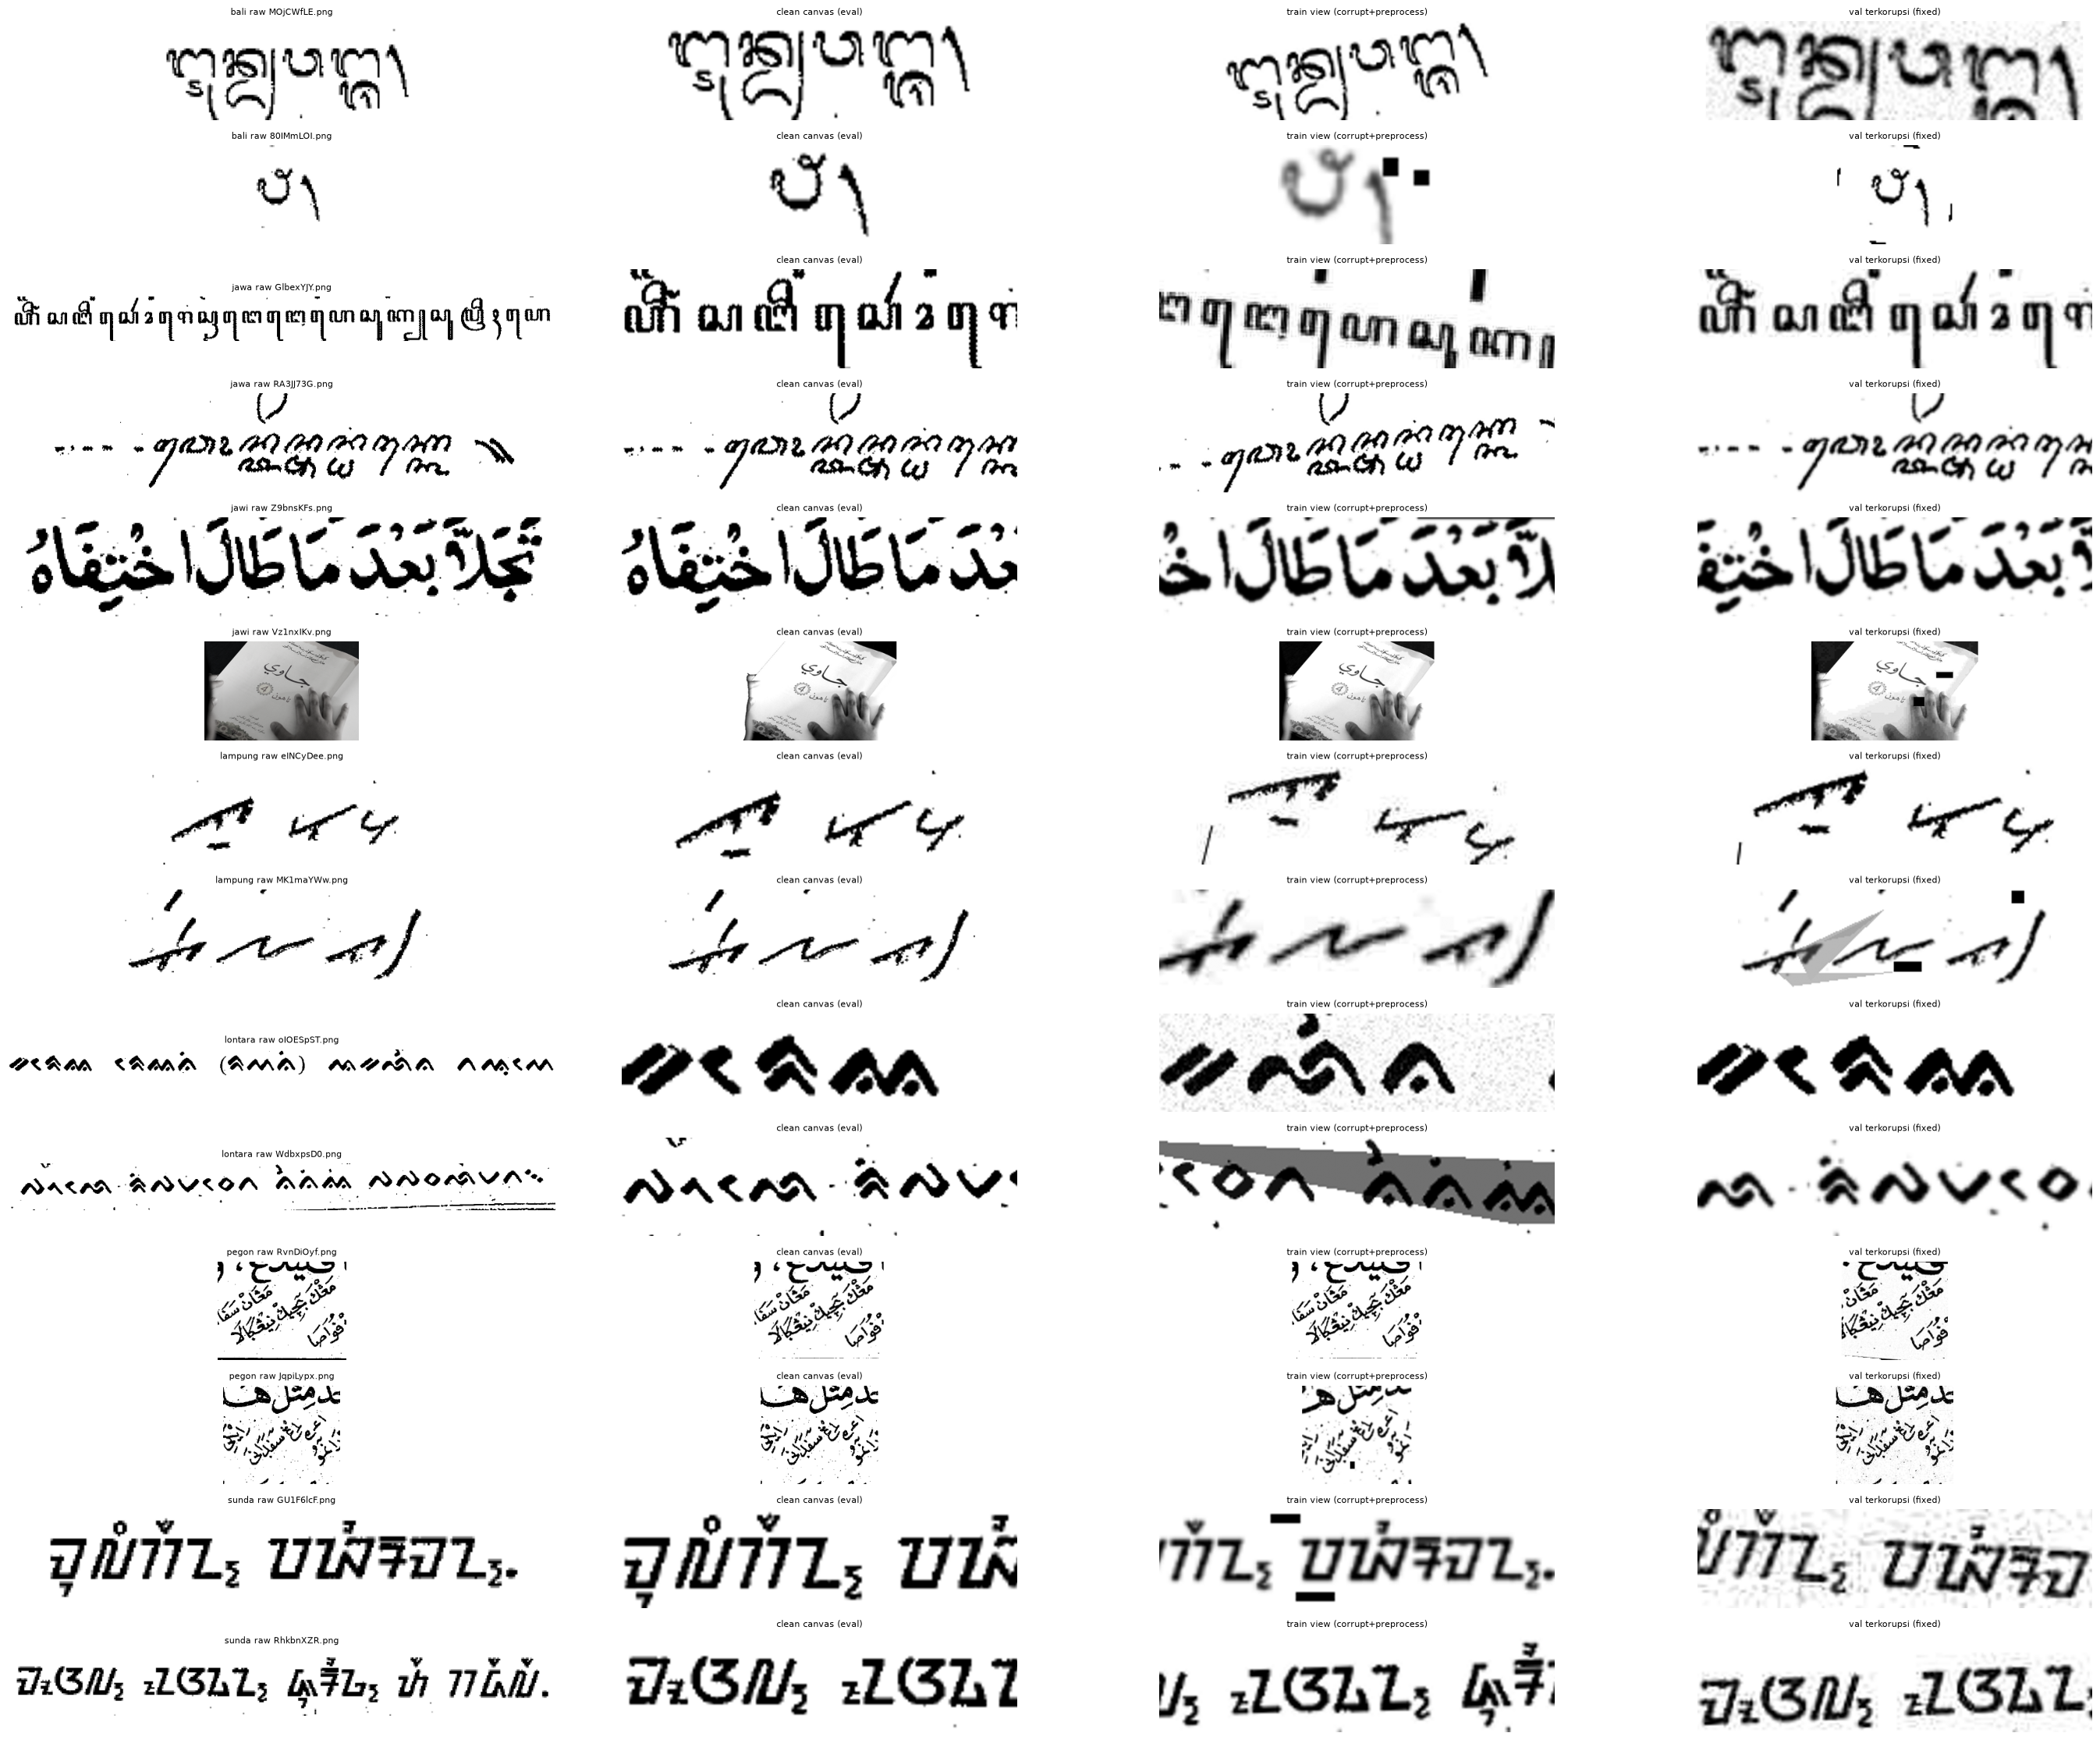

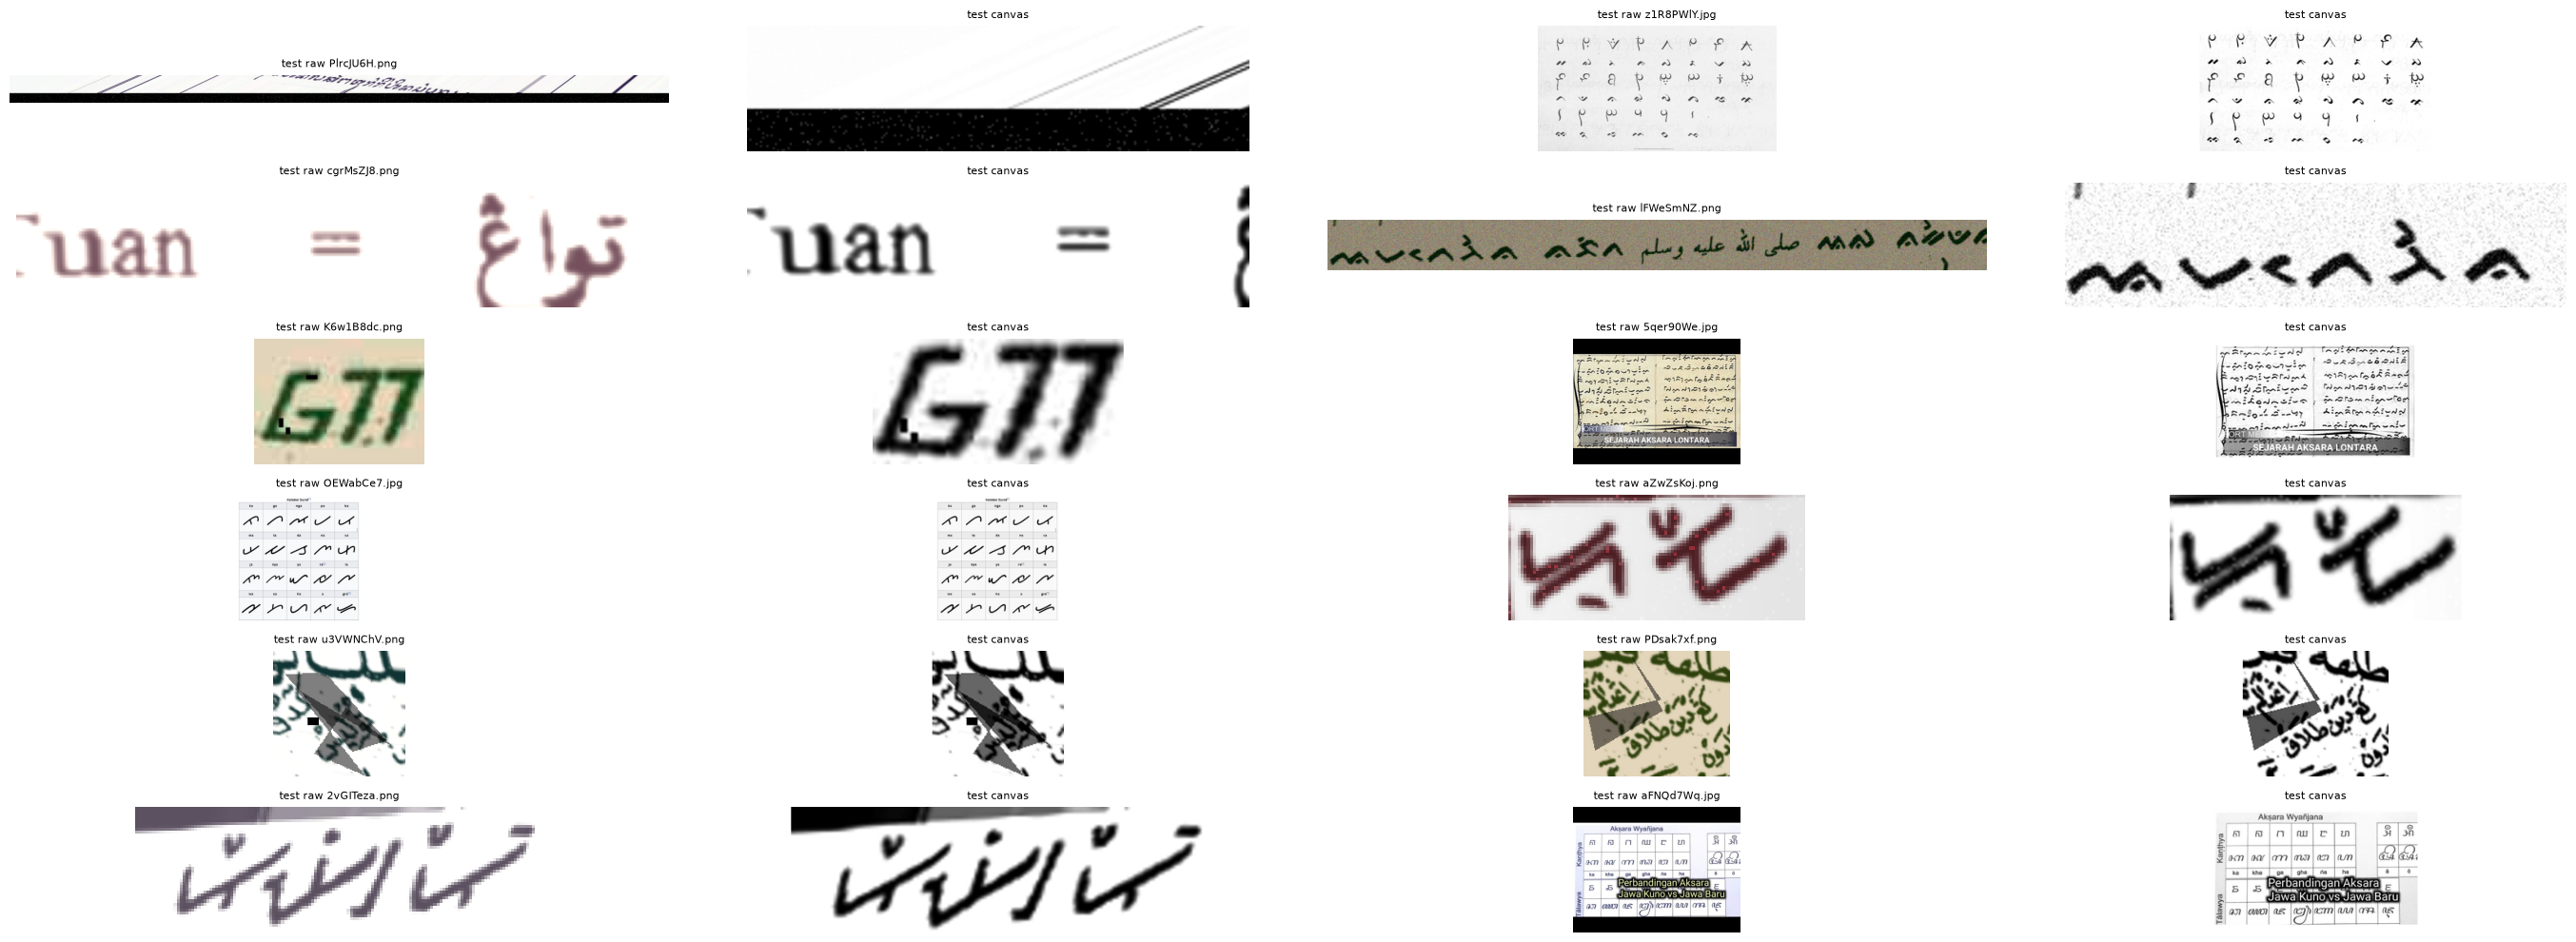

train clean  ink median=0.143  blank(<0.5%)=0.10%  >50% black=0.23%
val corrupt  ink median=0.144  blank(<0.5%)=0.14%  >50% black=0.55%
test         ink median=0.168  blank(<0.5%)=0.64%  >50% black=3.06%


In [6]:
MEAN_G = torch.tensor([0.485, 0.456, 0.406], device=DEVICE).view(1, 3, 1, 1)
STD_G = torch.tensor([0.229, 0.224, 0.225], device=DEVICE).view(1, 3, 1, 1)


def gpu_norm(x):  # uint8 (B,1,H,W) -> normalised float (B,3,H,W)
    return (x.float().div_(255).expand(-1, 3, -1, -1) - MEAN_G) / STD_G


class TrainDS(Dataset):
    # corrupt -> preprocess -> random window. Seed = (SEED, epoch, image) -> reproducible at any num_workers
    def __init__(self, idx, seed=SEED):
        self.idx, self.epoch, self.seed = np.asarray(idx), 0, seed

    def __len__(self):
        return len(self.idx)

    def __getitem__(self, i):
        j = int(self.idx[i])
        rng = random.Random(f'{self.seed}-{self.epoch}-{j}')
        v = to_canvas(preprocess(corrupt(Image.fromarray(train_raw[j]), rng)), H, W, train=True, rng=rng)[0]
        return torch.from_numpy(np.asarray(v, dtype=np.uint8).copy()).unsqueeze(0), int(y_all[j])


def subset_tiles(tiles, owner, idx):
    pos = {int(j): k for k, j in enumerate(idx)}
    m = np.isin(owner, idx)
    return tiles[m], np.array([pos[int(o)] for o in owner[m]])


@torch.inference_mode()
def predict_logits(model, tiles, owner, n):
    model.eval()
    out = torch.zeros(n, len(LABELS), dtype=torch.float64)
    cnt = torch.zeros(n, 1, dtype=torch.float64)
    for s in range(0, len(tiles), EVAL_BATCH):
        x = gpu_norm(torch.from_numpy(tiles[s:s + EVAL_BATCH]).to(DEVICE).unsqueeze(1))
        with torch.autocast('cuda', dtype=torch.bfloat16):
            lg = model(x).float().cpu().double()
        o = torch.from_numpy(owner[s:s + EVAL_BATCH]).long()
        out.index_add_(0, o, lg)
        cnt.index_add_(0, o, torch.ones(len(o), 1, dtype=torch.float64))
    assert (cnt > 0).all()
    return (out / cnt).numpy()


# visual check: per kelas raw | clean canvas | train view | val terkorupsi
ds_vis = TrainDS(np.arange(len(train)))
fig, axes = plt.subplots(len(LABELS) * 2, 4, figsize=(28, 3.2 * len(LABELS)))
for r, lab in enumerate(LABELS):
    for k, j in enumerate(train.index[train.label == lab].to_series().sample(2, random_state=r)):
        row = axes[2 * r + k]
        x, _ = ds_vis[j]
        row[0].imshow(train_raw[j]); row[0].set_title(f'{lab} raw {train.image_id[j]}', fontsize=8)
        row[1].imshow(clean_tiles[clean_owner == j][0], cmap='gray', vmin=0, vmax=255); row[1].set_title('clean canvas (eval)', fontsize=8)
        row[2].imshow(x[0], cmap='gray', vmin=0, vmax=255); row[2].set_title('train view (corrupt+preprocess)', fontsize=8)
        row[3].imshow(cor_tiles[cor_owner == j][0], cmap='gray', vmin=0, vmax=255); row[3].set_title('val terkorupsi (fixed)', fontsize=8)
        for a in row: a.axis('off')
plt.tight_layout(); plt.savefig(OUT / 'samples_train.png', dpi=60); plt.show(); plt.close(fig)

fig, axes = plt.subplots(6, 4, figsize=(28, 10))
for a, j in zip(axes.ravel()[::2], test.sample(12, random_state=0).index):
    a.imshow(Image.open(test.path[j]).convert('RGB')); a.set_title(f'test raw {test.image_id[j]}', fontsize=8); a.axis('off')
for a, j in zip(axes.ravel()[1::2], test.sample(12, random_state=0).index):
    a.imshow(test_tiles[test_owner == j][0], cmap='gray', vmin=0, vmax=255); a.set_title('test canvas', fontsize=8); a.axis('off')
plt.tight_layout(); plt.savefig(OUT / 'samples_test.png', dpi=60); plt.show(); plt.close(fig)

ink = lambda t: (t < 128).mean(axis=(1, 2))
for name, t in [('train clean', clean_tiles), ('val corrupt', cor_tiles), ('test', test_tiles)]:
    f = ink(t)
    print(f'{name:12s} ink median={np.median(f):.3f}  blank(<0.5%)={np.mean(f < .005):.2%}  >50% black={np.mean(f > .5):.2%}')
assert x.shape == (1, H, W) and x.dtype == torch.uint8

## Model, optimizer, training (CV multi-seed + full-data)

In [7]:
def make_model():
    m = timm.create_model(MODEL_NAME, pretrained=True, num_classes=len(LABELS), img_size=(H, W), global_pool='token')
    if GRAD_CKPT:
        m.set_grad_checkpointing(True)
    return m.to(DEVICE)


def make_optimizer(model):
    head_ids = {id(p) for p in model.get_classifier().parameters()}
    groups = param_groups_layer_decay(model, weight_decay=WEIGHT_DECAY, layer_decay=LAYER_DECAY, no_weight_decay_list=model.no_weight_decay())
    for g in groups:
        g['params'] = [p for p in g['params'] if id(p) not in head_ids]
    groups = [g for g in groups if g['params']]
    groups.append({'params': list(model.get_classifier().parameters()), 'weight_decay': WEIGHT_DECAY, 'lr_scale': HEAD_LR / BASE_LR})
    for g in groups:
        g['base_lr'] = BASE_LR * g.get('lr_scale', 1.0); g['lr'] = g['base_lr']
    assert sum(p.numel() for g in groups for p in g['params']) == sum(p.numel() for p in model.parameters())
    return torch.optim.AdamW(groups, lr=BASE_LR, fused=True)


def macro_f1(y, logits):
    return f1_score(y, logits.argmax(1), labels=list(range(len(LABELS))), average='macro', zero_division=0)


def train_model(tag, tr_idx, va_idx, seed, stop_after=None):
    # v2 recipe. va_idx=None -> full-data model: no val, trained stop_after epochs of the same EPOCHS-long schedule.
    done = OUT / f'{tag}_test_logits.npy'
    if done.exists():
        print(f'{tag}: sudah selesai, skip'); return
    seed_all(seed)
    model, t_start = make_model(), time.time()
    opt = make_optimizer(model)
    counts = np.bincount(y_all[tr_idx], minlength=len(LABELS))
    cw = 1 / np.sqrt(counts); cw = cw / cw.mean()
    crit = nn.CrossEntropyLoss(weight=torch.tensor(cw, dtype=torch.float32, device=DEVICE), label_smoothing=LABEL_SMOOTHING)
    samp_w = torch.tensor(train.weight.values[tr_idx] * np.where(nonline[tr_idx], NONLINE_BOOST, 1.0), dtype=torch.double)
    steps_per_epoch = (len(tr_idx) // MICRO_BATCH) // ACCUM
    total, warm = EPOCHS * steps_per_epoch, WARMUP_EPOCHS * steps_per_epoch
    def lr_factor(step):
        if step < warm:
            return (step + 1) / warm
        return 0.01 + 0.99 * 0.5 * (1 + math.cos(math.pi * min(1.0, (step - warm) / max(1, total - warm))))
    if va_idx is not None:
        vc = subset_tiles(clean_tiles, clean_owner, va_idx); vx = subset_tiles(cor_tiles, cor_owner, va_idx); y_va = y_all[va_idx]
    ds = TrainDS(tr_idx, seed=seed)
    best, best_state, stale, step, hist = -1.0, None, 0, 0, []
    n_epochs = EPOCHS if stop_after is None else stop_after
    torch.cuda.reset_peak_memory_stats()
    for epoch in range(n_epochs):
        ds.epoch = epoch
        sampler = WeightedRandomSampler(samp_w, num_samples=len(tr_idx), replacement=True,
                                        generator=torch.Generator().manual_seed(seed * 1000 + epoch))
        loader = DataLoader(ds, batch_size=MICRO_BATCH, sampler=sampler, num_workers=NUM_WORKERS, pin_memory=True, drop_last=True, prefetch_factor=4)
        model.train(); opt.zero_grad(set_to_none=True)
        t0, loss_sum, seen = time.time(), 0.0, 0
        for it, (x, y) in enumerate(loader, 1):
            x, y = gpu_norm(x.to(DEVICE, non_blocking=True)), y.to(DEVICE, non_blocking=True)
            with torch.autocast('cuda', dtype=torch.bfloat16):
                logits = model(x)
            loss = crit(logits.float(), y)
            assert torch.isfinite(loss), f'loss non-finite {tag} epoch {epoch} iter {it}'
            (loss / ACCUM).backward()
            if it % ACCUM == 0:
                for g in opt.param_groups:
                    g['lr'] = g['base_lr'] * lr_factor(step)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                opt.step(); opt.zero_grad(set_to_none=True); step += 1
            loss_sum += loss.item() * len(y); seen += len(y)
        rec = dict(tag=tag, epoch=epoch + 1, loss=loss_sum / seen, train_s=round(time.time() - t0), imgs_per_s=round(seen / (time.time() - t0)))
        if va_idx is not None:
            lc = predict_logits(model, *vc, len(va_idx)); lx = predict_logits(model, *vx, len(va_idx))
            rec.update(f1_clean=macro_f1(y_va, lc), f1_corrupt=macro_f1(y_va, lx))
            if rec['f1_corrupt'] > best:  # v2 selection rule (optimism measured at only 0.0005 in eda/14)
                best, stale = rec['f1_corrupt'], 0
                best_state = {n: v.detach().to('cpu', copy=True) for n, v in model.state_dict().items()}
                best_logits, best_epoch = (lc, lx), epoch + 1
            else:
                stale += 1
        hist.append(rec); print(json.dumps(rec), flush=True)
        if va_idx is not None and stale >= PATIENCE:
            print(f'early stop {tag} epoch {epoch + 1}'); break
    if va_idx is not None:
        model.load_state_dict(best_state)
        np.save(OUT / f'{tag}_val_idx.npy', va_idx)
        np.save(OUT / f'{tag}_oof_clean_logits.npy', best_logits[0]); np.save(OUT / f'{tag}_oof_corrupt_logits.npy', best_logits[1])
    pd.DataFrame(hist).to_csv(OUT / f'{tag}_history.csv', index=False)
    np.save(done, predict_logits(model, test_tiles, test_owner, len(test)))  # written last = marker
    print(f'{tag}: {"best f1_corrupt=%.4f @%d" % (best, best_epoch) if va_idx is not None else "full-data %d epochs" % n_epochs}'
          f' | {(time.time() - t_start) / 60:.1f} min | peak VRAM {torch.cuda.max_memory_allocated() / 2**30:.1f} GB')
    del model, opt, best_state
    gc.collect(); torch.cuda.empty_cache()

In [8]:
for s in CV_SEEDS:
    for k in FOLDS:
        train_model(f'cv_s{s}_f{k}', np.where(train.fold != k)[0], np.where(train.fold == k)[0], seed=s * 100 + k)

best_epochs = [int(pd.read_csv(p).sort_values('f1_corrupt').iloc[-1].epoch) for p in sorted(OUT.glob('cv_s*_f*_history.csv'))]
FULL_EPOCHS = int(np.median(best_epochs)) if best_epochs and not SMOKE_TEST else FULL_EPOCHS_FALLBACK
print('CV best epochs:', best_epochs, '-> full-data models train', FULL_EPOCHS, 'epochs of the', EPOCHS, '-epoch schedule')
for s in FULL_SEEDS:
    train_model(f'full_s{s}', np.arange(len(train)), None, seed=s, stop_after=FULL_EPOCHS)

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.21GB            

model.safetensors: downloading bytes:           |  0.00B            

{"tag": "cv_s7_f0", "epoch": 1, "loss": 1.3400925516765168, "train_s": 23, "imgs_per_s": 128, "f1_clean": 0.9471451980906831, "f1_corrupt": 0.9400105819653746}
{"tag": "cv_s7_f0", "epoch": 2, "loss": 0.5641127764544589, "train_s": 23, "imgs_per_s": 131, "f1_clean": 0.9667793600215363, "f1_corrupt": 0.9569867626473305}
{"tag": "cv_s7_f0", "epoch": 3, "loss": 0.5241496761111503, "train_s": 23, "imgs_per_s": 129, "f1_clean": 0.9804567567226385, "f1_corrupt": 0.9678210456109982}
{"tag": "cv_s7_f0", "epoch": 4, "loss": 0.5174960489285753, "train_s": 23, "imgs_per_s": 130, "f1_clean": 0.9777115497812049, "f1_corrupt": 0.9679027330948697}
{"tag": "cv_s7_f0", "epoch": 5, "loss": 0.5113826238728584, "train_s": 23, "imgs_per_s": 128, "f1_clean": 0.9823375389400691, "f1_corrupt": 0.9768282926424304}
{"tag": "cv_s7_f0", "epoch": 6, "loss": 0.5004711934226624, "train_s": 23, "imgs_per_s": 130, "f1_clean": 0.9815800096856829, "f1_corrupt": 0.973508443156261}
{"tag": "cv_s7_f0", "epoch": 7, "loss": 0

{"tag": "cv_s7_f3", "epoch": 1, "loss": 1.3339042888676866, "train_s": 23, "imgs_per_s": 130, "f1_clean": 0.9395598974403934, "f1_corrupt": 0.9310290169757552}
{"tag": "cv_s7_f3", "epoch": 2, "loss": 0.5511222350153517, "train_s": 23, "imgs_per_s": 130, "f1_clean": 0.9721101320237222, "f1_corrupt": 0.9605474597491999}
{"tag": "cv_s7_f3", "epoch": 3, "loss": 0.5254553512055823, "train_s": 23, "imgs_per_s": 129, "f1_clean": 0.9702343326646574, "f1_corrupt": 0.958811911744008}
{"tag": "cv_s7_f3", "epoch": 4, "loss": 0.5112087003728176, "train_s": 23, "imgs_per_s": 130, "f1_clean": 0.9801689703222711, "f1_corrupt": 0.968620345985857}
{"tag": "cv_s7_f3", "epoch": 5, "loss": 0.5085362809452605, "train_s": 23, "imgs_per_s": 130, "f1_clean": 0.9818735360663823, "f1_corrupt": 0.9645298940216943}
{"tag": "cv_s7_f3", "epoch": 6, "loss": 0.48997608873438325, "train_s": 23, "imgs_per_s": 130, "f1_clean": 0.9815625941822541, "f1_corrupt": 0.9690363461195551}
{"tag": "cv_s7_f3", "epoch": 7, "loss": 0

## OOF: per seed dan ensemble seed (split yang sama → rata-rata per fold jujur)

In [9]:
def sizes(p):
    with Image.open(p) as im:
        return im.size
ctype = np.array(['page' if h >= 250 else ('line' if w / h >= 2 else ('block' if w >= 80 else 'glyph')) for w, h in map(sizes, train.path)])

members = {}
for s in CV_SEEDS:
    if all((OUT / f'cv_s{s}_f{k}_test_logits.npy').exists() for k in FOLDS):
        members[f'seed{s}'] = {k: (np.load(OUT / f'cv_s{s}_f{k}_val_idx.npy'), np.load(OUT / f'cv_s{s}_f{k}_oof_clean_logits.npy'), np.load(OUT / f'cv_s{s}_f{k}_oof_corrupt_logits.npy')) for k in FOLDS}
V2 = ROOT / 'results/v2/main'
if all((V2 / f'fold{k}_oof_clean_logits.npy').exists() for k in FOLDS):
    members['v2 (seed42)'] = {k: (np.load(V2 / f'fold{k}_val_idx.npy'), np.load(V2 / f'fold{k}_oof_clean_logits.npy'), np.load(V2 / f'fold{k}_oof_corrupt_logits.npy')) for k in FOLDS}
assert members, 'belum ada seed CV yang lengkap'


def oof_of(names):
    idx = np.concatenate([members[names[0]][k][0] for k in FOLDS])
    for n in names:
        assert (np.concatenate([members[n][k][0] for k in FOLDS]) == idx).all(), 'fold split beda'
    sm = lambda a: torch.softmax(torch.from_numpy(a), 1).numpy()
    pc = np.mean([sm(np.concatenate([members[n][k][1] for k in FOLDS])) for n in names], 0)
    px = np.mean([sm(np.concatenate([members[n][k][2] for k in FOLDS])) for n in names], 0)
    return idx, pc, px


rows = []
combos = [[n] for n in members] + ([list(members)] if len(members) > 1 else []) + \
         ([[n for n in members if n.startswith('seed')]] if sum(n.startswith('seed') for n in members) > 1 else [])
combos = [list(c) for c in dict.fromkeys(tuple(c) for c in combos)]
for names in combos:
    idx, pc, px = oof_of(names)
    y, ct = y_all[idx], ctype[idx]
    tl = np.where((ct == 'page')[:, None], pc, px)  # eda/14: pages clean, others corrupted
    rows.append(dict(members=' + '.join(names), f1_clean=macro_f1(y, pc), f1_corrupt=macro_f1(y, px), f1_testlike=macro_f1(y, tl),
                     page_acc_clean=(pc.argmax(1)[ct == 'page'] == y[ct == 'page']).mean(), line_acc_corrupt=(px.argmax(1)[ct == 'line'] == y[ct == 'line']).mean()))
oof_tab = pd.DataFrame(rows).round(4)
display(oof_tab); oof_tab.to_csv(OUT / 'oof_members.csv', index=False)

,members,f1_clean,f1_corrupt,f1_testlike,page_acc_clean,line_acc_corrupt
0,seed7,0.9806,0.9741,0.9759,0.7889,0.9919
1,seed2026,0.9816,0.9728,0.9757,0.7839,0.9926
2,seed7 + seed2026,0.9809,0.9739,0.9767,0.7940,0.9919


## Submissions A / B / C
Rata-rata probabilitas anggota (setiap model bobot sama), twin override. Selisih antar file dicetak supaya selisih LB bisa dibaca dengan `eda/12_lb_forensics.py`.

In [10]:
sm = lambda a: torch.softmax(torch.from_numpy(a), 1).numpy()
cv_m = [OUT / f'cv_s{s}_f{k}_test_logits.npy' for s in CV_SEEDS for k in FOLDS]
full_m = [OUT / f'full_s{s}_test_logits.npy' for s in FULL_SEEDS]
v2_m = [ROOT / f'results/v2/main/fold{k}_test_logits.npy' for k in FOLDS]
cv_m, full_m, v2_m = [p for p in cv_m if p.exists()], [p for p in full_m if p.exists()], [p for p in v2_m if p.exists()]
print(f'members: cv {len(cv_m)} | full {len(full_m)} | v2 {len(v2_m)}')
assert cv_m, 'belum ada model CV selesai'


def write(paths, name):
    p = np.mean([sm(np.load(q)) for q in paths], 0)
    pred = np.array(LABELS, dtype=object)[p.argmax(1)]
    if USE_TWINS and len(twins):
        tw = test.image_id.map(twins.set_index('image_id').train_label); m = tw.notna().values
        pred[m] = tw[m].values
    sub = sample_sub[['image_id']].merge(pd.DataFrame({'image_id': test.image_id, 'label': pred}), on='image_id', how='left')
    assert len(sub) == len(sample_sub) and sub.label.notna().all() and set(sub.label) <= set(LABELS)
    sub.to_csv(OUT / name, index=False)
    pd.DataFrame(p, columns=LABELS).assign(image_id=test.image_id.values).to_csv(OUT / name.replace('submission', 'probs'), index=False)
    return sub.set_index('image_id').label


subs = {'A_cv': write(cv_m, 'submission_A_cv.csv')}
if full_m:
    subs['B_cv_full'] = write(cv_m + full_m, 'submission_B_cv_full.csv')
if full_m and v2_m:
    subs['C_plus_v2'] = write(cv_m + full_m + v2_m, 'submission_C_plus_v2.csv')
for v, p in [('v2_LB0.915', ROOT / 'results/v2/main/submission.csv'), ('v3_LB0.891', ROOT / 'results/v3/main/submission.csv')]:
    if p.exists():
        subs[v] = pd.read_csv(p).set_index('image_id').label.reindex(sample_sub.image_id)
names = list(subs)
dis = pd.DataFrame([[int((subs[a].reindex(sample_sub.image_id).values != subs[b].reindex(sample_sub.image_id).values).sum()) for b in names] for a in names], index=names, columns=names)
print('rows that differ between submissions:'); display(dis)
tt = pd.Series(['page' if h >= 250 else ('line' if w / h >= 2 else ('block' if w >= 80 else 'glyph')) for w, h in map(sizes, test.path)], index=test.image_id)
if 'v2_LB0.915' in subs:
    for n in [x for x in names if x[0] in 'ABC']:
        d = subs[n].reindex(sample_sub.image_id).values != subs['v2_LB0.915'].reindex(sample_sub.image_id).values
        print(f'{n} vs v2 differs on {d.sum()} rows, by type {tt.reindex(sample_sub.image_id)[d].value_counts().to_dict()}')
display(pd.DataFrame({n: subs[n].value_counts(normalize=True) * 100 for n in names}).reindex(LABELS).round(1))

config = {k: v for k, v in dict(globals()).items() if k.isupper() and isinstance(v, (int, float, str, bool, list, tuple))}
config.update(torch=torch.__version__, timm=timm.__version__, python=platform.python_version(), gpu=torch.cuda.get_device_name())
(OUT / 'config.json').write_text(json.dumps(config, indent=2, default=str))
print('SELESAI ->', sorted(p.name for p in OUT.glob('submission_*.csv')))

members: cv 10 | full 3 | v2 0
rows that differ between submissions:


,A_cv,B_cv_full
A_cv,0,12
B_cv_full,12,0


,A_cv,B_cv_full
label,,
bali,9.3,9.5
jawa,18.3,18.0
jawi,13.4,13.3
lampung,19.1,19.0
lontara,9.0,8.9
pegon,17.4,17.6
sunda,13.5,13.7


SELESAI -> ['submission_A_cv.csv', 'submission_B_cv_full.csv']
